In [13]:
!pip install torch torchvision matplotlib

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader

In [15]:
!wget http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2shoes.tar.gz
!tar -xvf edges2shoes.tar.gz

Streaming output truncated to the last 5000 lines.
edges2shoes/train/46382_AB.jpg
edges2shoes/train/46383_AB.jpg
edges2shoes/train/46384_AB.jpg
edges2shoes/train/46385_AB.jpg
edges2shoes/train/46386_AB.jpg
edges2shoes/train/46387_AB.jpg
edges2shoes/train/46388_AB.jpg
edges2shoes/train/46389_AB.jpg
edges2shoes/train/4638_AB.jpg
edges2shoes/train/46390_AB.jpg
edges2shoes/train/46391_AB.jpg
edges2shoes/train/46392_AB.jpg
edges2shoes/train/449_AB.jpg
edges2shoes/train/44_AB.jpg
edges2shoes/train/45000_AB.jpg
edges2shoes/train/45001_AB.jpg
edges2shoes/train/45002_AB.jpg
edges2shoes/train/45003_AB.jpg
edges2shoes/train/45004_AB.jpg
edges2shoes/train/45005_AB.jpg
edges2shoes/train/45006_AB.jpg
edges2shoes/train/45007_AB.jpg
edges2shoes/train/45008_AB.jpg
edges2shoes/train/45009_AB.jpg
edges2shoes/train/4500_AB.jpg
edges2shoes/train/45010_AB.jpg
edges2shoes/train/45011_AB.jpg
edges2shoes/train/45012_AB.jpg
edges2shoes/train/45013_AB.jpg
edges2shoes/train/45687_AB.jpg
edges2shoes/train/45688_AB

In [16]:
class Edges2ShoesDataset(Dataset):

    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.image_files = os.listdir(root_dir)

        self.transform = transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):

        img_path = os.path.join(self.root_dir, self.image_files[index])
        image = Image.open(img_path).convert("RGB")

        w, h = image.size

        edge = image.crop((0,0,w/2,h))
        real = image.crop((w/2,0,w,h))

        edge = self.transform(edge)
        real = self.transform(real)

        return edge, real

In [17]:
train_dataset = Edges2ShoesDataset("edges2shoes/train")
test_dataset = Edges2ShoesDataset("edges2shoes/val")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [18]:
class UNetDown(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True):
        super().__init__()

        layers = [nn.Conv2d(in_channels,out_channels,4,2,1,bias=False)]

        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))

        layers.append(nn.LeakyReLU(0.2))

        self.model = nn.Sequential(*layers)

    def forward(self,x):
        return self.model(x)


class UNetUp(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.model = nn.Sequential(
            nn.ConvTranspose2d(in_channels,out_channels,4,2,1,bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self,x,skip):
        x = self.model(x)
        x = torch.cat((x,skip),1)
        return x

In [19]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1 = UNetDown(3,64,normalize=False)
        self.down2 = UNetDown(64,128)
        self.down3 = UNetDown(128,256)
        self.down4 = UNetDown(256,512)

        self.up1 = UNetUp(512,256)
        self.up2 = UNetUp(512,128)
        self.up3 = UNetUp(256,64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):

        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)

        u1 = self.up1(d4,d3)
        u2 = self.up2(u1,d2)
        u3 = self.up3(u2,d1)

        return self.final(u3)

In [20]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(6,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,512,4,1,1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512,1,4,1,1)
        )

    def forward(self,edge,real):

        x = torch.cat((edge,real),1)
        return self.model(x)

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [22]:
adversarial_loss = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()

In [23]:
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5,0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5,0.999))

In [24]:
epochs = 1

for epoch in range(epochs):

    for i,(edge,real) in enumerate(train_loader):

        edge = edge.to(device)
        real = real.to(device)

        valid = torch.ones((edge.size(0),1,30,30)).to(device)
        fake = torch.zeros((edge.size(0),1,30,30)).to(device)

        # ---------------------
        # Train Generator
        # ---------------------

        optimizer_G.zero_grad()

        fake_img = generator(edge)

        pred_fake = discriminator(edge,fake_img)

        g_adv = adversarial_loss(pred_fake,valid)

        g_l1 = l1_loss(fake_img,real)

        g_loss = g_adv + 100*g_l1

        g_loss.backward()
        optimizer_G.step()

        # ---------------------
        # Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        pred_real = discriminator(edge,real)
        loss_real = adversarial_loss(pred_real,valid)

        pred_fake = discriminator(edge,fake_img.detach())
        loss_fake = adversarial_loss(pred_fake,fake)

        d_loss = (loss_real + loss_fake)/2

        d_loss.backward()
        optimizer_D.step()

        if i % 100 == 0:
            print(f"Epoch {epoch} Batch {i} | D Loss {d_loss.item()} | G Loss {g_loss.item()}")

Epoch 0 Batch 0 | D Loss 0.7222739458084106 | G Loss 95.92926025390625
Epoch 0 Batch 100 | D Loss 1.0844287872314453 | G Loss 24.80429458618164
Epoch 0 Batch 200 | D Loss 0.6151138544082642 | G Loss 22.305879592895508
Epoch 0 Batch 300 | D Loss 0.3595576584339142 | G Loss 20.42273712158203
Epoch 0 Batch 400 | D Loss 0.43651852011680603 | G Loss 27.5316104888916
Epoch 0 Batch 500 | D Loss 0.1578565537929535 | G Loss 24.947101593017578
Epoch 0 Batch 600 | D Loss 0.2952585816383362 | G Loss 24.247243881225586
Epoch 0 Batch 700 | D Loss 0.22136187553405762 | G Loss 20.962841033935547
Epoch 0 Batch 800 | D Loss 0.11387293040752411 | G Loss 23.433652877807617
Epoch 0 Batch 900 | D Loss 0.302524596452713 | G Loss 23.178382873535156
Epoch 0 Batch 1000 | D Loss 0.10902263224124908 | G Loss 25.66879653930664
Epoch 0 Batch 1100 | D Loss 0.10475713014602661 | G Loss 20.67525863647461
Epoch 0 Batch 1200 | D Loss 0.052009567618370056 | G Loss 28.40406608581543
Epoch 0 Batch 1300 | D Loss 0.127854570

In [25]:
edge,real = next(iter(test_loader))

edge = edge.to(device)

generator.eval()

with torch.no_grad():
    fake = generator(edge)

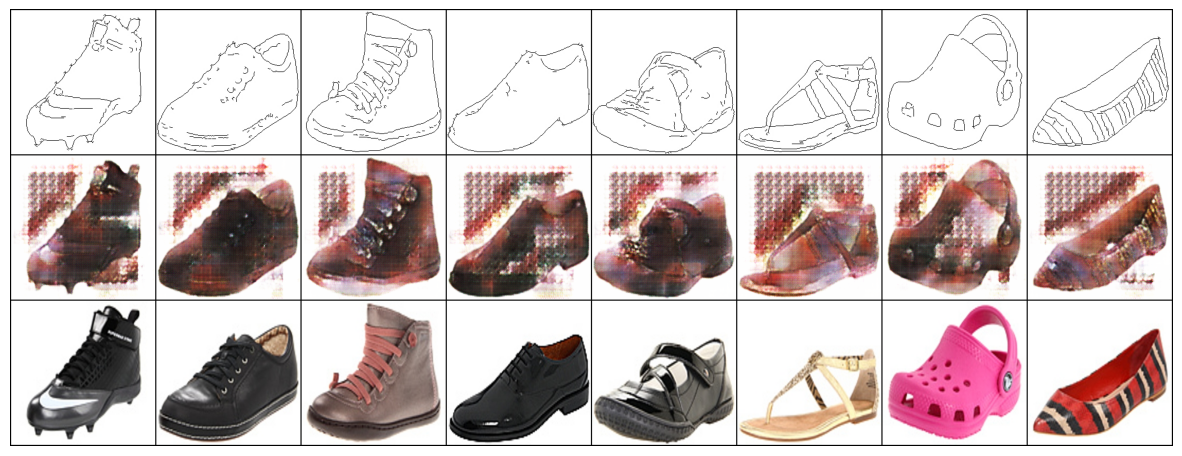

In [26]:
def show_images(edges,fake,real):

    edges = edges.cpu()*0.5+0.5
    fake = fake.cpu()*0.5+0.5
    real = real.cpu()*0.5+0.5

    grid = torch.cat((edges,fake,real),0)

    grid = make_grid(grid,nrow=8)

    plt.figure(figsize=(15,10))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")

show_images(edge,fake,real)

In [27]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.ReLU(),
            nn.Conv2d(64,128,4,2,1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x